In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df=pd.read_csv("/content/employe.csv")

In [30]:
df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [32]:
df.isnull()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
14994,False,False,False,False,False,False,False,False,False,False
14995,False,False,False,False,False,False,False,False,False,False
14996,False,False,False,False,False,False,False,False,False,False
14997,False,False,False,False,False,False,False,False,False,False


In [33]:
df.isnull().sum()

,0
satisfactoryLevel,0
lastEvaluation,0
numberOfProjects,0
avgMonthlyHours,0
timeSpent.company,0
workAccident,0
left,0
promotionInLast5years,0
dept,0
salary,0


In [34]:
df.describe()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [35]:
print("Total Number of Employees :",len(df))

Total Number of Employees : 14999


In [36]:
print("Number of Employees who currently work for the company :",df[df['left']==0].shape[0])

Number of Employees who currently work for the company : 11428


In [37]:
print("Number of Employees who left the company :",df[df['left']==1].shape[0])

Number of Employees who left the company : 3571


**Insight**

From 14999 Employees,3571 Employees left and currently 11428 Employees work for the company.

In [38]:
d_left_count=df[df['left']==1]['dept'].value_counts()
print(d_left_count)

dept
sales          1014
technical       697
support         555
IT              273
hr              215
accounting      204
marketing       203
product_mng     198
RandD           121
management       91
Name: count, dtype: int64


In [39]:
d_left_mean=df.groupby('dept')['left'].mean().sort_values(ascending=False)
print(d_left_mean)

dept
hr             0.290934
accounting     0.265971
technical      0.256250
support        0.248991
sales          0.244928
marketing      0.236597
IT             0.222494
product_mng    0.219512
RandD          0.153748
management     0.144444
Name: left, dtype: float64


In [40]:
print(len(df[df['dept']=='hr']))

739


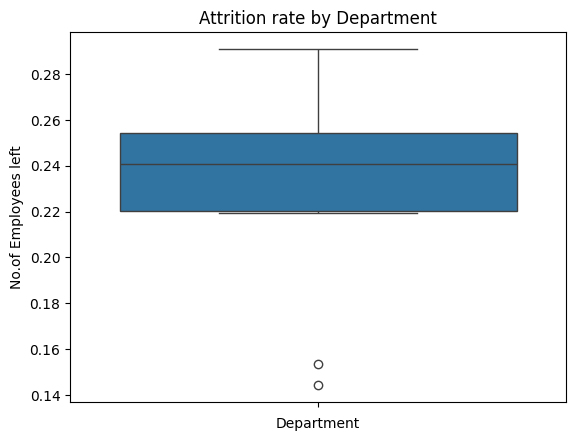

In [41]:
sns.boxplot(d_left_mean)
plt.title("Attrition rate by Department")
plt.xlabel("Department")
plt.ylabel("No.of Employees left")
plt.show()

**Insight**
* HR department is having the highest rates of attrition -> 0.290934

* 215 employees out of 739 have left the HR department

* Sales department has the highest attrition count -> 1014




In [42]:
less_projects=df[df['numberOfProjects']<3]
high_projects=df[df['numberOfProjects']>=3]

In [43]:
less_attrition_rate = less_projects['left'].value_counts(normalize=True)[1]*100
high_attrition_rate = high_projects['left'].value_counts(normalize=True)[1]*100

In [44]:
print("Attrition rate lesser than 3 projects :",less_attrition_rate)
print("Attrition rate greater than 3 projects :",high_attrition_rate)

Attrition rate lesser than 3 projects : 65.61976549413735
Attrition rate greater than 3 projects : 15.89088890651019


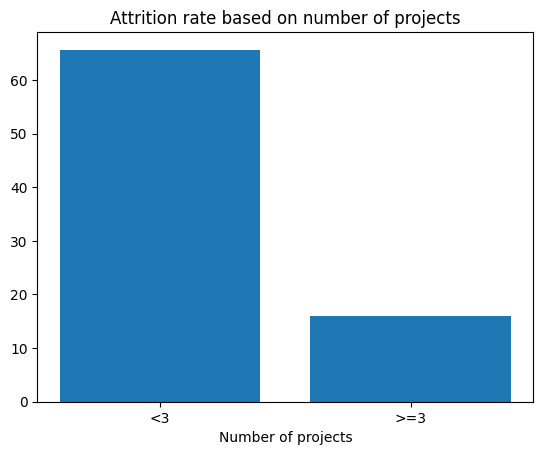

In [45]:
labels=['<3','>=3']
values=[less_attrition_rate,high_attrition_rate]
plt.bar(labels,values)
plt.title('Attrition rate based on number of projects')
plt.xlabel('Number of projects')
plt.show()

**Insight**
*   65.62% of employees working on fewer than 3 projects are more likely to leave the company.

*    where, only 15.89% of employees working on 3 or more projects are likely to leave the company.

In [46]:
left_emp=df[df['left']==1]

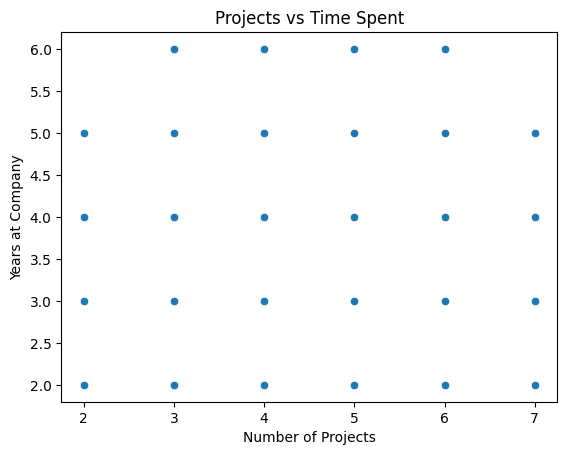

In [47]:
sns.scatterplot(data=left_emp,x='numberOfProjects',y='timeSpent.company')
plt.title('Projects vs Time Spent')
plt.xlabel('Number of Projects')
plt.ylabel('Years at Company')
plt.show()

**Insight**


*   Employees with both less and more project counts have left at different times.
*    The scatter plot shows there is no relationship between the number of projects and the time spent at the company.



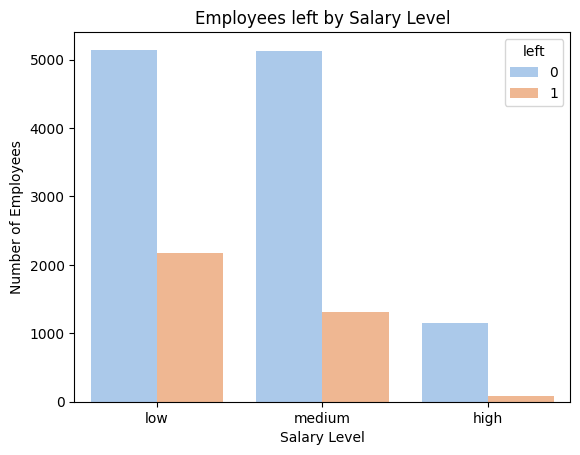

In [48]:
sns.countplot(data=df,x='salary',hue='left',palette='pastel')
plt.title('Employees left by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Number of Employees')
plt.show()

**Insight**
*  A Large number of employees with low and medium salaries have left the company.
*  High salary employees are more likely to stay within the company.





In [49]:
corr=df.select_dtypes(include=["number"]).corr()
corr

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years
satisfactoryLevel,1.000000,0.105021,-0.142970,-0.020048,-0.100866,0.058697,-0.388375,0.025605
lastEvaluation,0.105021,1.000000,0.349333,0.339742,0.131591,-0.007104,0.006567,-0.008684
numberOfProjects,-0.142970,0.349333,1.000000,0.417211,0.196786,-0.004741,0.023787,-0.006064
avgMonthlyHours,-0.020048,0.339742,0.417211,1.000000,0.127755,-0.010143,0.071287,-0.003544
timeSpent.company,-0.100866,0.131591,0.196786,0.127755,1.000000,0.002120,0.144822,0.067433
workAccident,0.058697,-0.007104,-0.004741,-0.010143,0.002120,1.000000,-0.154622,0.039245
left,-0.388375,0.006567,0.023787,0.071287,0.144822,-0.154622,1.000000,-0.061788
promotionInLast5years,0.025605,-0.008684,-0.006064,-0.003544,0.067433,0.039245,-0.061788,1.000000


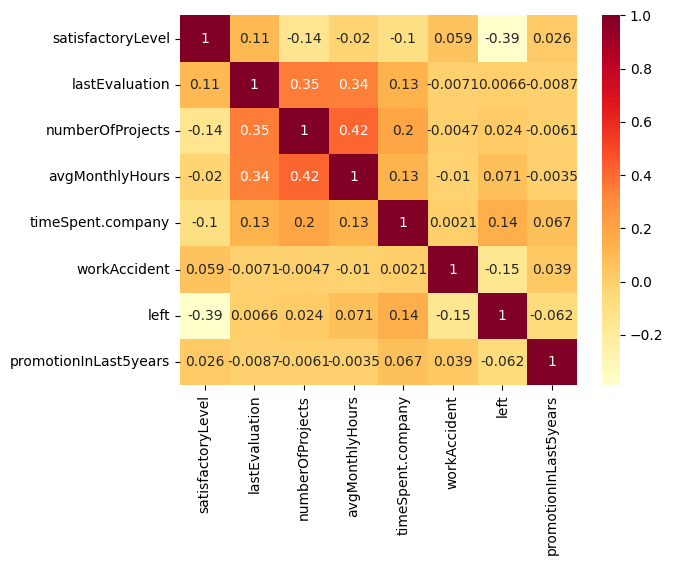

In [50]:
sns.heatmap(corr,cmap="YlOrRd",annot=True)
plt.show()

**Conclusion**

By analysing the given data using statical summaries and visualizations,we can conclude that the employees having fewer projects and lower salaries are more likely to leave the company.